<a href="https://colab.research.google.com/github/Dark-Knight17/keystroke-dynamics-thesis/blob/main/keystroke_cnn_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, LSTM, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('All imports successful.')

TensorFlow version: 2.20.0
All imports successful.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 1: LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/Keystroke_data/events_with_abs_timestamps_30P_23_may_final.csv'

df = pd.read_csv(DATA_PATH)
df = df.sort_values(by=['session_id', 'event_sequence']).reset_index(drop=True)

# Encode physical_code as integer index (stable across the full dataset)
encoder = LabelEncoder()
df['physical_code_encoded'] = encoder.fit_transform(df['physical_code'].astype(str))

print(f'Loaded {len(df):,} events from {df["session_id"].nunique()} sessions '
      f'across {df["participant_id"].nunique()} participants.')
print(f'Physical key vocabulary size: {df["physical_code"].nunique()}')

Loaded 184,278 events from 441 sessions across 51 participants.
Physical key vocabulary size: 83


In [ ]:
MAX_TIMESTEPS = 300
NUM_FEATURES  = 3

sequence_data  = []
padding_masks  = []
session_labels = []

for session_id, grp in df.groupby('session_id'):
    kd = grp[grp['event_type'] == 'keydown'].copy()
    if len(kd) < 10:
        continue

    f_code   = kd['physical_code_encoded'].values.astype('float32')
    f_flight = kd['timestamp'].diff().fillna(0).clip(0, 2000).values.astype('float32')
    f_text   = kd['text_length'].values.astype('float32')

    seq = np.stack([f_code, f_flight, f_text], axis=1)
    seq = seq[-MAX_TIMESTEPS:]
    real_len = len(seq)

    if real_len < MAX_TIMESTEPS:
        pad = np.zeros((MAX_TIMESTEPS - real_len, NUM_FEATURES), dtype='float32')
        seq = np.vstack([pad, seq])

    mask = np.array([False] * (MAX_TIMESTEPS - real_len) + [True] * real_len)

    sequence_data.append(seq)
    padding_masks.append(mask)
    session_labels.append(grp['participant_id'].iloc[0])

X_all        = np.array(sequence_data, dtype='float32')
M_all        = np.array(padding_masks, dtype=bool)
labels       = np.array(session_labels)
unique_users = np.unique(labels)

# ── Filter to complete users only (12 sessions attempted in DB) ───────────
db_session_count  = df.groupby('participant_id')['session_id'].nunique()
complete_user_ids = db_session_count[db_session_count >= 12].index
keep         = np.isin(labels, complete_user_ids)
X_all        = X_all[keep]
M_all        = M_all[keep]
labels       = labels[keep]
unique_users = np.unique(labels)

print(f'Complete users (12 sessions in DB) : {len(unique_users)}')
print(f'Total sessions after filtering     : {len(labels)}')


# ── Verify session counts for all complete users ──────────────────────────
print('\nSession counts per complete user:')
print(pd.Series(labels).value_counts().sort_values())
print(f'\nExpected: 30 users, all with 12 or more sessions')

Complete users (12 sessions in DB) : 30
Total sessions after filtering     : 362

Session counts per complete user:
50678107-eec1-46bc-997f-5f9332d816d0    12
84862943-81f9-4052-a7c3-4f687cfdd383    12
395665da-8c41-460a-9812-25abd1eb7583    12
07c7a634-bc94-4a69-8d27-9e1bad1328fa    12
717a1053-e594-4106-8841-be8e7e79d8fc    12
e64abcec-f872-471e-bfe1-310388d70914    12
8336c671-5956-4974-a72b-73811efa642a    12
2d472fd6-c638-4de1-9f86-145d0eceed18    12
cbefa558-ab10-4db9-b13a-844c346ce46f    12
5f4c0735-d72c-497d-b281-887a25052483    12
c4357602-10c4-46c5-a2cf-99765fe37a0b    12
b4fd3127-994c-4fd8-a9b6-aa636356d593    12
f5c7e4a7-8a3f-4a48-8b5b-087856e050da    12
6ead2ae1-202f-4952-b1c6-518a90b5b4d4    12
6a484554-0145-4226-9c05-65b113934ade    12
cd227289-9996-4a7a-a8dd-f38975b147a1    12
e6bcbd2e-fcb9-48a5-9f71-f90c8d60474d    12
8eb9019c-3b95-4345-bf27-a9f21a7373de    12
57637896-54dc-482e-866b-709ed168699c    12
88d1b920-a64f-48a2-aae9-6fa69ec726a0    12
96ef1c00-b710-4568-99fa-

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 3: FEATURE NORMALISATION
#
# Normalise each feature channel independently using only real (non-padded)
# timesteps. Uses the explicit boolean mask M_all built in Cell 4, which is
# more reliable than inferring padding from sum != 0.
# After normalisation, padded positions are re-zeroed so they remain neutral.
# ─────────────────────────────────────────────────────────────────────────────

X_norm = X_all.copy()
stats  = {}

for f, name in enumerate(['physical_code', 'flight_time', 'text_length']):
    vals = X_all[:, :, f][M_all]   # only real (non-padded) values
    mu, sigma = vals.mean(), vals.std() + 1e-8
    X_norm[:, :, f] = (X_all[:, :, f] - mu) / sigma
    stats[name] = (mu, sigma)

X_norm[~M_all] = 0.0

print('Feature normalisation complete.')
for name, (mu, sigma) in stats.items():
    print(f'  {name:<20} mean: {mu:.2f},  std: {sigma:.2f}')

Feature normalisation complete.
  physical_code        mean: 47.71,  std: 22.58
  flight_time          mean: 432.48,  std: 480.93
  text_length          mean: 143.27,  std: 117.45


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 4: MODEL DEFINITION
#
# FIX: Remove Masking layer — it is silently destroyed by Conv1D and creates
# a false sense of correctness while doing nothing for the LSTM.
# Pre-padding with zeros + feature normalisation is the correct substitute.
# ─────────────────────────────────────────────────────────────────────────────

def build_model(max_timesteps, num_features):
    model = Sequential([
        Input(shape=(max_timesteps, num_features)),

        # CNN block 1 — local temporal pattern extraction
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # CNN block 2 — higher-level rhythm patterns
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # LSTM — sequential dependency modelling
        LSTM(units=64, return_sequences=False),
        Dropout(0.4),

        Dense(units=32, activation='relu'),
        Dropout(0.3),

        # Binary output: 1 = genuine, 0 = impostor
        Dense(units=1, activation='sigmoid')
    ], name='CNN_LSTM_Biometric')

    # FIX: Do NOT use accuracy as a primary metric — it is misleading under
    # severe class imbalance.  Use AUC and report EER post-training.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

# Quick summary to confirm no Masking layer
demo = build_model(MAX_TIMESTEPS, NUM_FEATURES)
demo.summary()

Model: "CNN_LSTM_Biometric"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 300, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,633 (303.25 KB)

 Trainable params: 77,249 (301.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 5: EVALUATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def compute_eer(y_true, y_scores):
    """
    Compute Equal Error Rate (EER) — the standard biometric authentication
    metric.  EER is the threshold at which FAR (False Acceptance Rate) equals
    FRR (False Rejection Rate).  Lower EER = better authentication.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    # Find the threshold where |FPR - FNR| is minimised
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]
    return eer, eer_threshold, fpr, tpr


def evaluate_user(user_id, X, labels, verbose=False):
    """
    Full leave-one-out evaluation for a single user:
    - Genuine: all sessions belonging to user_id
    - Impostor TRAIN: sessions from ALL other users (used only for training)
    - Test set: ALL genuine sessions + a balanced impostor test set
    """
    genuine_mask  = labels == user_id
    impostor_mask = ~genuine_mask

    X_genuine  = X[genuine_mask]
    X_impostor = X[impostor_mask]
    n_genuine  = len(X_genuine)

    if n_genuine < 4:
        return None  # not enough genuine samples to evaluate

    # ── FIX: CLASS IMBALANCE — undersample impostors to 5:1 ratio ─────────
    # With 12 genuine sessions, we use at most 60 impostor sessions for
    # training to keep the ratio manageable. This is combined with
    # class_weight to further compensate for remaining imbalance.
    n_impostor_train = min(len(X_impostor), n_genuine * 5)
    rng = np.random.default_rng(seed=42)
    imp_idx = rng.choice(len(X_impostor), n_impostor_train, replace=False)
    X_imp_train = X_impostor[imp_idx]

    # ── BUILD TRAIN / TEST SETS ────────────────────────────────────────────
    # Leave 3 genuine sessions out for testing (25% of 12 = 3)
    # Train on remaining genuine + sampled impostors
    n_test_genuine   = max(3, n_genuine // 4)
    n_train_genuine  = n_genuine - n_test_genuine

    perm = rng.permutation(n_genuine)
    X_gen_test  = X_genuine[perm[:n_test_genuine]]
    X_gen_train = X_genuine[perm[n_test_genuine:]]

    # Test impostor: use sessions NOT in training set
    test_imp_idx  = np.setdiff1d(np.arange(len(X_impostor)), imp_idx)
    n_test_imp    = min(len(test_imp_idx), n_test_genuine * 10)
    test_imp_idx  = rng.choice(test_imp_idx, n_test_imp, replace=False) if len(test_imp_idx) > n_test_imp else test_imp_idx
    X_imp_test    = X_impostor[test_imp_idx]

    # Assemble arrays
    X_train = np.vstack([X_gen_train, X_imp_train])
    y_train = np.concatenate([np.ones(n_train_genuine), np.zeros(n_impostor_train)])

    X_test  = np.vstack([X_gen_test, X_imp_test])
    y_test  = np.concatenate([np.ones(n_test_genuine), np.zeros(len(X_imp_test))])

    # ── FIX: CLASS WEIGHT ─────────────────────────────────────────────────
    classes = np.array([0, 1])
    cw      = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight = {0: cw[0], 1: cw[1]}

    if verbose:
        print(f'User: {user_id[:8]}...')
        print(f'  Train: {n_train_genuine} genuine + {n_impostor_train} impostor')
        print(f'  Test:  {n_test_genuine} genuine + {len(X_imp_test)} impostor')
        print(f'  class_weight: {class_weight}')

    # ── TRAIN MODEL ───────────────────────────────────────────────────────
    tf.keras.backend.clear_session()
    model = build_model(MAX_TIMESTEPS, NUM_FEATURES)

    early_stop = EarlyStopping(
        monitor='val_auc', mode='max', patience=5,
        restore_best_weights=True, verbose=0
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=30,
        batch_size=8,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0
    )

    # ── EVALUATE ──────────────────────────────────────────────────────────
    y_scores = model.predict(X_test, verbose=0).ravel()
    y_pred   = (y_scores >= 0.5).astype(int)

    try:
        auc  = roc_auc_score(y_test, y_scores)
        eer, eer_thresh, fpr, tpr = compute_eer(y_test, y_scores)
    except ValueError:
        auc, eer = float('nan'), float('nan')
        fpr, tpr = np.array([0,1]), np.array([0,1])
        eer_thresh = 0.5

    results = {
        'user_id'    : user_id,
        'auc'        : auc,
        'eer'        : eer,
        'eer_thresh' : eer_thresh,
        'f1'         : f1_score(y_test, y_pred, zero_division=0),
        'precision'  : precision_score(y_test, y_pred, zero_division=0),
        'recall'     : recall_score(y_test, y_pred, zero_division=0),
        'fpr'        : fpr,
        'tpr'        : tpr,
        'n_genuine'  : n_genuine,
        'y_test'     : y_test,
        'y_scores'   : y_scores,
    }

    if verbose:
        print(f'  AUC: {auc:.3f}   EER: {eer:.3f}   F1: {results["f1"]:.3f}')

    return results

print('Evaluation helpers defined.')

Evaluation helpers defined.


Demo evaluation for user: 07c7a634-bc94-4a69-8d27-9e1bad1328fa

User: 07c7a634...
  Train: 9 genuine + 60 impostor
  Test:  3 genuine + 30 impostor
  class_weight: {0: np.float64(0.575), 1: np.float64(3.8333333333333335)}
  AUC: 1.000   EER: 0.000   F1: 0.214

Results:
  AUC       : 1.0000
  EER       : 0.0000  (threshold: 0.9020)
  F1 Score  : 0.2143
  Precision : 0.1200
  Recall    : 1.0000


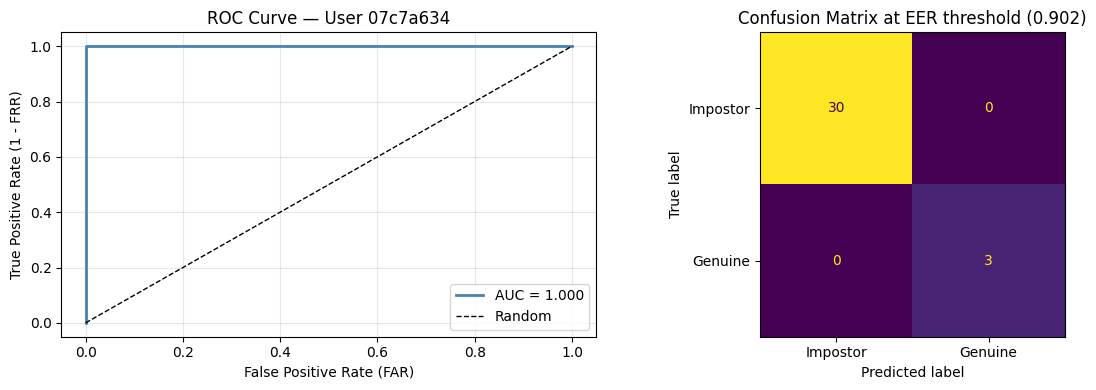

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 6: SINGLE-USER DEMO EVALUATION
# Evaluate the first user to verify the pipeline before running all 50 users.
# ─────────────────────────────────────────────────────────────────────────────

target_user = unique_users[0]
print(f'Demo evaluation for user: {target_user}\n')

result = evaluate_user(target_user, X_norm, labels, verbose=True)

if result:
    print(f'\nResults:')
    print(f'  AUC       : {result["auc"]:.4f}')
    print(f'  EER       : {result["eer"]:.4f}  (threshold: {result["eer_thresh"]:.4f})')
    print(f'  F1 Score  : {result["f1"]:.4f}')
    print(f'  Precision : {result["precision"]:.4f}')
    print(f'  Recall    : {result["recall"]:.4f}')

    # DET curve for this user
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(result['fpr'], result['tpr'], color='steelblue', lw=2, label=f'AUC = {result["auc"]:.3f}')
    axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
    axes[0].set_xlabel('False Positive Rate (FAR)')
    axes[0].set_ylabel('True Positive Rate (1 - FRR)')
    axes[0].set_title(f'ROC Curve — User {target_user[:8]}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    cm = confusion_matrix(result['y_test'], (result['y_scores'] >= result['eer_thresh']).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=['Impostor','Genuine']).plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f'Confusion Matrix at EER threshold ({result["eer_thresh"]:.3f})')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Keystroke_data/demo_user_eval.png', dpi=150)
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 7: FULL LEAVE-ONE-OUT EVALUATION ACROSS ALL USERS
#
# This is the correct LOO protocol:
#   For each enrolled user U (all 26 participants):
#     - Train: U's genuine sessions + sampled impostors
#     - Test:  held-out genuine sessions of U + unseen impostors
#   Report: mean EER, mean AUC across all 26 users
# ─────────────────────────────────────────────────────────────────────────────

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# ── FULL LEAVE-ONE-OUT EVALUATION (all 26 complete users) ─────────────────
all_results = []

for i, user in enumerate(unique_users):
    print(f'[{i+1:02d}/{len(unique_users)}] {user[:8]}...', end=' ')
    res = evaluate_user(user, X_norm, labels, verbose=False)
    if res is not None:
        all_results.append(res)
        print(f'AUC={res["auc"]:.3f}  EER={res["eer"]:.3f}')
    else:
        print('SKIPPED (insufficient genuine sessions)')

print(f'\nEvaluation complete: {len(all_results)}/{len(unique_users)} users evaluated.')

[01/30] 07c7a634... AUC=0.933  EER=0.050
[02/30] 0a54ac81... AUC=0.611  EER=0.350
[03/30] 0d7d8c14... AUC=0.722  EER=0.233
[04/30] 2d472fd6... AUC=0.733  EER=0.233
[05/30] 395665da... AUC=0.622  EER=0.267
[06/30] 4269a402... AUC=0.767  EER=0.250
[07/30] 50678107... AUC=0.322  EER=0.733
[08/30] 57637896... AUC=0.689  EER=0.283
[09/30] 5f4c0735... AUC=1.000  EER=0.000
[10/30] 6a484554... AUC=0.822  EER=0.367
[11/30] 6c555496... AUC=0.944  EER=0.050
[12/30] 6ead2ae1... AUC=0.511  EER=0.383
[13/30] 709ad166... AUC=1.000  EER=0.000
[14/30] 70ec2e58... AUC=0.567  EER=0.650
[15/30] 717a1053... AUC=0.567  EER=0.317
[16/30] 729fb63c... AUC=0.678  EER=0.267
[17/30] 7e5cdd79... AUC=0.933  EER=0.067
[18/30] 8336c671... AUC=0.878  EER=0.283
[19/30] 84862943... AUC=0.956  EER=0.067
[20/30] 88d1b920... AUC=0.633  EER=0.367
[21/30] 8eb9019c... AUC=1.000  EER=0.000
[22/30] 96ef1c00... AUC=0.733  EER=0.250
[23/30] b4fd3127... AUC=0.522  EER=0.367
[24/30] c4357602... AUC=0.711  EER=0.333
[25/30] cbefa558

CNN-LSTM BIOMETRIC AUTHENTICATION — SUMMARY RESULTS
Users evaluated      : 30
Mean AUC             : 0.7315  (± 0.1786)
Mean EER             : 0.2817  (± 0.1818)
Mean F1              : 0.2110  (± 0.1876)
Median EER           : 0.2833
Best EER             : 0.0000
Worst EER            : 0.7333
Results saved to Google Drive.


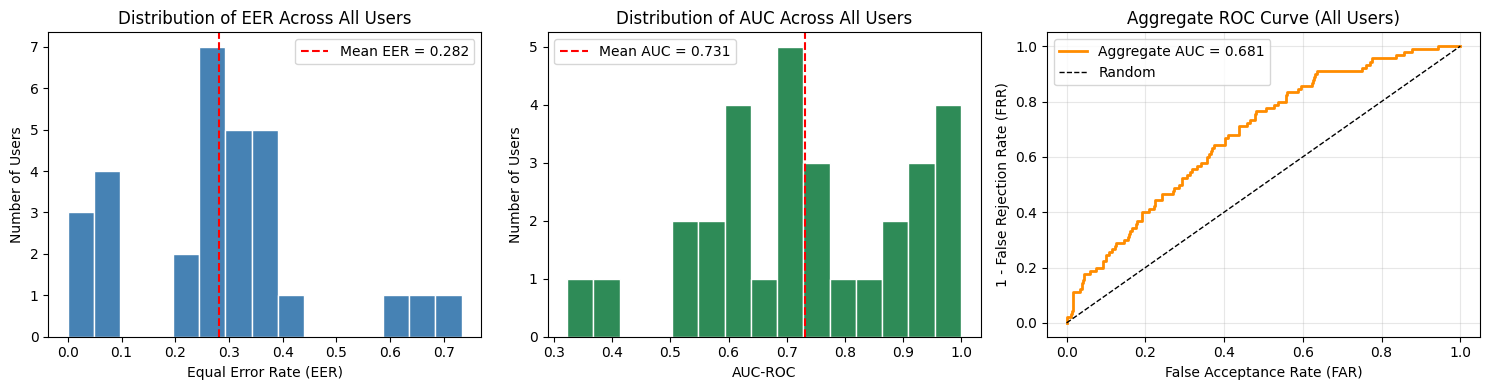

Summary plots saved.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 8: AGGREGATE RESULTS & THESIS REPORTING
# ─────────────────────────────────────────────────────────────────────────────

results_df = pd.DataFrame([{
    'user_id'   : r['user_id'],
    'auc'       : r['auc'],
    'eer'       : r['eer'],
    'f1'        : r['f1'],
    'precision' : r['precision'],
    'recall'    : r['recall'],
    'n_genuine' : r['n_genuine'],
} for r in all_results])

print('=' * 55)
print('CNN-LSTM BIOMETRIC AUTHENTICATION — SUMMARY RESULTS')
print('=' * 55)
print(f'Users evaluated      : {len(results_df)}')
print(f'Mean AUC             : {results_df["auc"].mean():.4f}  (± {results_df["auc"].std():.4f})')
print(f'Mean EER             : {results_df["eer"].mean():.4f}  (± {results_df["eer"].std():.4f})')
print(f'Mean F1              : {results_df["f1"].mean():.4f}  (± {results_df["f1"].std():.4f})')
print(f'Median EER           : {results_df["eer"].median():.4f}')
print(f'Best EER             : {results_df["eer"].min():.4f}')
print(f'Worst EER            : {results_df["eer"].max():.4f}')
print('=' * 55)

# Save results
results_df.to_csv('/content/drive/MyDrive/Keystroke_data/cnn_lstm_loo_results.csv', index=False)
print('Results saved to Google Drive.')

# ── VISUALISATIONS ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(results_df['eer'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(results_df['eer'].mean(), color='red', linestyle='--', label=f'Mean EER = {results_df["eer"].mean():.3f}')
axes[0].set_xlabel('Equal Error Rate (EER)')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Distribution of EER Across All Users')
axes[0].legend()

axes[1].hist(results_df['auc'].dropna(), bins=15, color='seagreen', edgecolor='white')
axes[1].axvline(results_df['auc'].mean(), color='red', linestyle='--', label=f'Mean AUC = {results_df["auc"].mean():.3f}')
axes[1].set_xlabel('AUC-ROC')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Distribution of AUC Across All Users')
axes[1].legend()

# Aggregate DET curve
all_y_true   = np.concatenate([r['y_test'] for r in all_results])
all_y_scores = np.concatenate([r['y_scores'] for r in all_results])
agg_fpr, agg_tpr, _ = roc_curve(all_y_true, all_y_scores)
agg_auc = roc_auc_score(all_y_true, all_y_scores)

axes[2].plot(agg_fpr, agg_tpr, color='darkorange', lw=2, label=f'Aggregate AUC = {agg_auc:.3f}')
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[2].set_xlabel('False Acceptance Rate (FAR)')
axes[2].set_ylabel('1 - False Rejection Rate (FRR)')
axes[2].set_title('Aggregate ROC Curve (All Users)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Keystroke_data/cnn_lstm_summary_plots.png', dpi=150)
plt.show()
print('Summary plots saved.')